# Tarea 1: Diseño y Construcción de la Arquitectura (RAAP):

1. En un Jupyter Notebook, diseña y construye una Red Neuronal Convolucional
(CNN) utilizando TensorFlow y Keras.

2. La arquitectura debe incluir al menos dos capas de convolución (Conv2D), dos
capas de MaxPooling2D, una capa Flatten y dos capas Dense.

3. Justifica en celdas de Markdown cada elección de diseño:

    3.1  ¿Qué tamaño de kernel se ha seleccionado?

    3.2  ¿Qué función tiene la capa de pooling?

    3.3  ¿Qué has aplicado para prevenir el problema del gradiente desvanecido?

    3.4  Evalúa también el uso de Softmax en tu solución.







In [ ]:
#Limpiar RAM
import gc
import numpy as np

# Limpiar variables antiguas
gc.collect()

# Forzar liberación de memoria de arrays grandes
try:
    del X_train
    del X_test
    del y_train
    del y_test
except:
    pass

gc.collect()

0

In [ ]:
# ========================================================================================
# ========================================================================================
    #PARTE 1: "Arquitectura y Entrenamiento de una Red Convolucional (CNN)" (RAAP)
# ========================================================================================
# ========================================================================================
#!pip install tensorflow.keras.to_categorical
#!pip install pandas
from google.colab import drive
drive.mount('/content/drive')
# ============================================
# Importamos librerias que necesitamos
# ============================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Cargar el CSV de TRAIN (el que sí tiene label)
train_df = pd.read_csv("/content/drive/MyDrive/CIFAR-10/train.csv")

print("Shape train_df:", train_df.shape)



Shape train_df: (50000, 3073)


In [ ]:
# 2. Separar X_train (píxeles) e y_train (etiquetas)
y_train = train_df["label"].values
X_train = train_df.drop(columns=["label"]).values

print(X_train.shape, y_train.shape)

(50000, 3072) (50000,)


In [ ]:
# 3. Reconstruir imágenes 32x32x3
X_train = X_train.reshape(-1, 32, 32, 3)
print("X_train después de reshape:", X_train.shape)

X_train después de reshape: (50000, 32, 32, 3)


In [ ]:
# 4. Normalizar y one-hot
X_train = X_train / 255.0
y_train = to_categorical(y_train, 10)

print("X_train final:", X_train.shape)
print("y_train final:", y_train.shape)

X_train final: (50000, 32, 32, 3)
y_train final: (50000, 10)


In [ ]:
# TEST: solo imágenes, sin etiquetas
test_df = pd.read_csv("/content/drive/MyDrive/CIFAR-10/test.csv")
print("Shape test_df:", test_df.shape)

X_test = test_df.values
print("X_test antes de reshape:", X_test.shape)

X_test = X_test.reshape(-1, 32, 32, 3)
X_test = X_test.astype("float32") / 255.0

print("X_test después de reshape y normalización:", X_test.shape)

Shape test_df: (10000, 3072)
X_test antes de reshape: (10000, 3072)
X_test después de reshape y normalización: (10000, 32, 32, 3)


**3.1 ¿Qué tamaño de kernel se ha seleccionado?**

Tamaño de kernel: 3x3 porque es **estandar** en CNN modernas,tien un **buen coste computacional y rapidez**.

**3.2 ¿Qué función tiene la capa de pooling?**

El pooling **reduce el tamaño de la image**,esto sirve para:

  *   Simplificar la información, reduce la resolución espacial
  *   Reduce que el modelo memorice(overfitting)
  *   Extrae características más robustas, es decir, mantiene las características más importantes

En este modelo se usa pooling 2×2, que reduce a la mitad el tamaño de la imagen en cada paso.

**3.3 ¿Qué se ha aplicado para prevenir el gradiente desvanecido?**

Se han aplicado **dos técnicas**:

**1.Batch Normalization (he_normal)**
  *   Normaliza las activaciones de cada capa:
  *   Ayuda a que los valores iniciales de los pesos no sean ni muy grandes ni muy pequeños.
  *   Estabiliza el flujo del gradiente
  *   Permite entrenar más rápido y con mayor profundidad

**2.Función de activación ReLU**
  *   Evita que los gradientes se vuelvan demasiado pequeños
  *   Mantiene gradientes constantes para valores positivos
  *   Reduce el riesgo de gradiente desvanecido
  *   Es rápida y funciona muy bien en CNNs

**3.4 Evalúa también el uso de Softmax en tu solución**

Se utiliza para la clasificación multiclase porque:
  *   Convierte las salidas en probabilidades
  *   Cada probabilidad está entre 0 y 1
  *   La suma total es 1
  *   Facilita interpretar la clase más probable
  *   Funciona perfectamente con la pérdida categorical_crossentropy


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3), #Se usa drowout en el modelo

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Entrenamos con menos imagenes porque colab se queda sin memoria
X_train_small = X_train[:20000]
y_train_small = y_train[:20000]


history = model.fit(
    X_train_small, y_train_small,
    epochs=5, #antes  10 y 20, se quedaba sin memoria Colab
    batch_size=16, #antes 32, 64 se quedaba sin memoria Colab
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 116s 91ms/step - accuracy: 0.2997 - loss: 1.9858 - val_accuracy: 0.4788 - val_loss: 1.4537
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 135s 85ms/step - accuracy: 0.4516 - loss: 1.5103 - val_accuracy: 0.5269 - val_loss: 1.3317
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 116s 93ms/step - accuracy: 0.5223 - loss: 1.3284 - val_accuracy: 0.4683 - val_loss: 1.6549
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 134s 87ms/step - accuracy: 0.5662 - loss: 1.2071 - val_accuracy: 0.4786 - val_loss: 1.6022
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 113s 90ms/step - accuracy: 0.6038 - loss: 1.1033 - val_accuracy: 0.5681 - val_loss: 1.2651


*   **Dropout**: apaga aleatoriamente neuronas durante el entrenamiento para evitar que el modelo memorice el conjunto de entrenamiento.Forma parte del modelo por lo que se debe definir antes de compilarlo y se ejecuta durante el entrenamiento.
*   **EarlyStopping**: es un callback (no forma parte del modelo)detiene el entrenamiento cuando la validación deja de mejorar, evitando sobreentrenar.Se define antes del entrenamiento pero se ejecuta durante el entrenamiento.





In [ ]:
# Esto libera:
# - pesos temporales
# - gradientes
# - grafo computacional
# - memoria de GPU/CPU

import gc
import tensorflow as tf

gc.collect()
tf.keras.backend.clear_session()

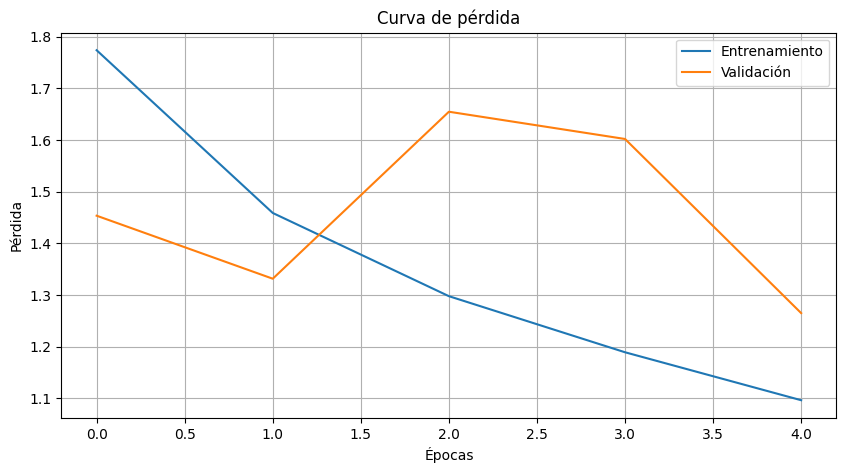

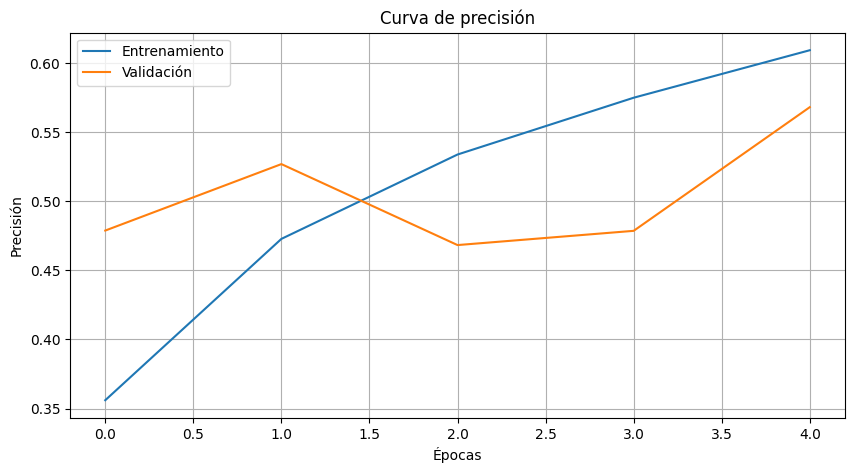

In [ ]:
import matplotlib.pyplot as plt

# Pérdida
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curva de pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

# Precisión
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Curva de precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)
plt.show()


*   La pérdida de entrenamiento (loss) desciende de forma constante.
- La pérdida de validación desciende más lentamente y se estabiliza antes.
- La precisión de entrenamiento (accuracy) sube rápido.
- La precisión de validación sube más despacio y se queda por debajo de la de entrenamiento.
Esto indica:
- El modelo aprende correctamente las características básicas del dataset.
- Existe un ligero sobreajuste, normal en una CNN pequeña entrenada desde cero.
- EarlyStopping ha evitado que el modelo memorice en exceso.

**Conclusión**:
La CNN converge, pero su capacidad de generalización es limitada debido a la complejidad del dataset.


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


<Figure size 1000x1000 with 0 Axes>

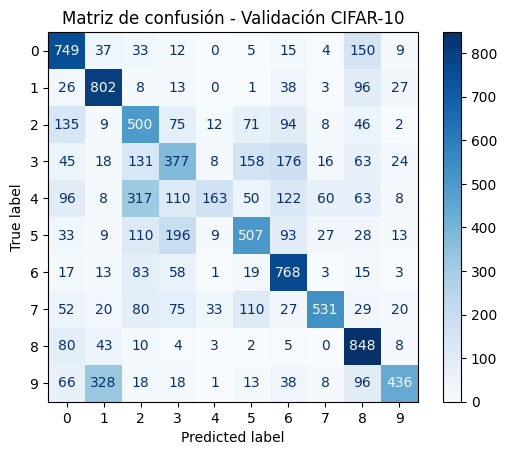

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

#Matriz de confusión (usando el 20% de validación)
#Como no tenemos y_test, usamos las predicciones del conjunto de validación interno.


# Obtener índices del conjunto de validación
val_size = int(0.2 * len(X_train))

X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

# Predicciones
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
cm
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10,10))
disp.plot(cmap='Blues', values_format='d')
plt.title("Matriz de confusión - Validación CIFAR-10")
plt.show()

La matriz de confusión de tu CNN muestra:
- Una diagonal dominante, lo que indica que el modelo clasifica correctamente la mayoría de las imágenes.

- Varias confusiones sistemáticas entre clases visualmente similares:

Confusiones típicas observadas
- cat ↔ dog
Ambos comparten texturas, colores y formas similares.
- automobile ↔ truck
Vehículos con geometrías parecidas en baja resolución.
- deer ↔ horse
Siluetas y colores similares.
- bird ↔ airplane en algunos casos
Especialmente cuando el fondo es cielo.
Estas confusiones son normales en CIFAR‑10, especialmente con modelos pequeños.

**Conclusión:**

La CNN identifica bien las clases con patrones visuales fuertes (ship, frog, airplane), pero falla más en clases con alta similitud semántica o visual.
